## Exercises from Chapter 5: Pretraining on unlabeled data 

In [1]:
# Adding the repo root to sys.path
from pathlib import Path
import sys

# Current folder:
# repository_root/chapter_04/exercises
# i.e. 
# import os  
# print(os.getcwd()) # prints: c:\Users\delmi\Documents\LEARNING\Manning_Learning\repos\build-llm-from-scratch-pytorch\chapter_04\exercises 
# Note: Python searches for chapter_03 (and all other needed imports) inside that folder and in the other locations listed in sys.path. but sys.path currently does not have the repo root
# the snippet below adds the repo root to sys.path

repo_root = Path.cwd().parents[1]

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)
sys.path

Repository root: c:\Users\delmi\Documents\LEARNING\Manning_Learning\repos\build-llm-from-scratch-pytorch


['c:\\Users\\delmi\\Documents\\LEARNING\\Manning_Learning\\repos\\build-llm-from-scratch-pytorch',
 'C:\\Users\\delmi\\anaconda3\\python312.zip',
 'C:\\Users\\delmi\\anaconda3\\DLLs',
 'C:\\Users\\delmi\\anaconda3\\Lib',
 'C:\\Users\\delmi\\anaconda3',
 'c:\\Users\\delmi\\venvs\\llmbookvenv',
 '',
 'c:\\Users\\delmi\\venvs\\llmbookvenv\\Lib\\site-packages']

### 5.1 Evaluating generative text models

#### 5.1.1 Using GPT to generate text

In [2]:
import torch
from chapter_04.scripts.gpt import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False    
}
GPT_CONFIG_124M.update({"context_length": 256}) # change is done for us to train the model on a standard laptop computer. Otherwise the 1,024 setting would be too compute intensive

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAtt

In [3]:
import tiktoken
from chapter_04.scripts.gpt import generate_text_simple

# utility functions for text to token ID conversion
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<endoftext>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor # returns a tensor : batch of token IDs. Ex: tensor([[6109, 3626, 6100,  345]]) 

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
text_to_token_ids(start_context, tokenizer)

tensor([[6109, 3626, 6100,  345]])

In [5]:
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer), # ex: tensor([[6109, 3626, 6100,  345]])
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
token_ids

tensor([[ 6109,  3626,  6100,   345, 34245,  5139,  2492, 25405, 17434, 17853,
          5308,  3398, 13174, 43071]])

In [6]:
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### 5.1.2 Calculating the text generation loss

In [7]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]

In [8]:
with torch.no_grad():
    logits = model(inputs)
# logits = logits[:, -1, :] # In case we just want to focus on the last token
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [9]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [10]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [11]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4536e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6771e-05, 4.7559e-06])


In [12]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7765, -12.2561])


In [13]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [14]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


In [15]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [16]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [17]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


### 5.1.3 Calculating the training and validation set losses

In [18]:
file_path = "../../chapter_02/data/the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [19]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [20]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [21]:
from chapter_02.scripts.data_pipeline import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [22]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [23]:
data_iter = iter(train_loader)
a,b = next(data_iter)
print(a.shape, b.shape)

torch.Size([2, 256]) torch.Size([2, 256])


In [24]:
a.shape

torch.Size([2, 256])

In [70]:
def calc_loss_batch(input_batch, target_batch, model, device): # calculates the loss for a single batch
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0,1), target_batch.flatten() #first argument is the predicted labels, second argument is the actual labels
    )
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None): # num_batches can be set as a smaller number if we want to speedup evaluation during training
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches == None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
    return loss/num_batches

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: tensor(10.9994)
Validation loss: tensor(10.9811)


## 5.2 Training an LLM

In [27]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [28]:
# This takes around 5 min!!
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.885, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.389, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.288, Val loss 7.048
Ep 2 (Step 000015): Train loss 6.116, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.238, Val loss 6.598
Ep 3 (Step 000025): Train loss 5.149, Val loss 6.351
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 3.958, Val loss 6.279
Ep 4 (Step 000035): Train loss 4.095, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.928, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

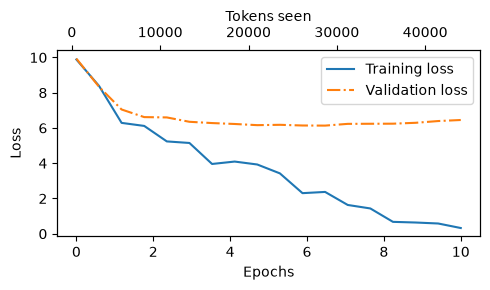

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 5.3 Decoding strategies to control randomness

In [30]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


### 5.3.1 Temperature scaling

In [31]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}

In [32]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [33]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [34]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
             for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [35]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

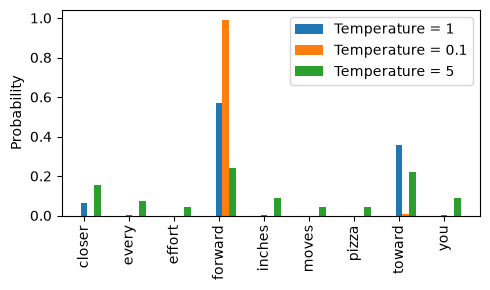

In [36]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
                for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], 
                   bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 5.1
Use the print_sampled_tokens function to print the sampling frequencies of the softmax probabilities scaled with the temperatures shown in figure 5.14. How often is the word pizza sampled in each case? Can you think of a faster and more accurate way to determine how often the word pizza is sampled?

In [37]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)


temperatures = [1, 0.1, 5]

scaled_probas = [
    softmax_with_temperature(next_token_logits, T)
    for T in temperatures
]

pizza_idx = vocab["pizza"]

for T, probas in zip(temperatures, scaled_probas):
    print(
        f"Temperature {T}: "
        f"P(pizza) = {probas[pizza_idx].item():.4f}"
    )

Temperature 1: P(pizza) = 0.0001
Temperature 0.1: P(pizza) = 0.0000
Temperature 5: P(pizza) = 0.0430


In [38]:
# Exercise 5.1

temperatures = [1, 0.1, 5]

scaled_probas = [
    softmax_with_temperature(next_token_logits, T)
    for T in temperatures
]

# 1) Estimate sampling frequency using 1000 random samples
for T, probas in zip(temperatures, scaled_probas):
    print(f"\nTemperature = {T}")
    print_sampled_tokens(probas)

# 2) Faster and more accurate: directly inspect pizza's probability
pizza_idx = vocab["pizza"]

for T, probas in zip(temperatures, scaled_probas):
    print(
        f"Temperature {T}: "
        f"P(pizza) = {probas[pizza_idx].item() * 100:.2f}%"
    )


Temperature = 1
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward

Temperature = 0.1
0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward

Temperature = 5
165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you
Temperature 1: P(pizza) = 0.01%
Temperature 0.1: P(pizza) = 0.00%
Temperature 5: P(pizza) = 4.30%


### 5.3.2 Top-k sampling

In [39]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [40]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [41]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### **Binomial and Multinomial distributions and how they relate to top-k and probability sampling in LLMs**
**Binomial distribution:** Models the number of successes in a fixed number of independent trials, where each trial has two possible outcomes.

- **Input:** Number of trials $n$, success probability $p$
- **Output:** Probability of getting $k$ successes, where $k = 0, \dots, n$

```math
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
```

**Multinomial distribution:** Generalizes the binomial distribution to more than two possible outcomes per trial.

- **Input:** Number of trials $n$, category probabilities $(p_1, \dots, p_K)$
- **Output:** Probability of getting counts $(k_1, \dots, k_K)$, where $\sum_{i=1}^{K} k_i = n$

```math
P(X_1=k_1,\dots,X_K=k_K)
=
\frac{n!}{k_1!\cdots k_K!}
\prod_{i=1}^{K} p_i^{k_i}
```


**Crisp intuition:**

> **Binomial:** “How many successes out of $n$?”  
> **Multinomial:** “How many times did each of $K$ categories occur out of $n$?”

**Relation to top-k sampling in LLMs:** Top-k sampling first keeps only the $k$ highest-probability next tokens and renormalizes their probabilities so they sum to 1. The model then *samples one token from this probability distribution*.

> **Top-k decides which tokens are allowed; multinomial sampling decides which allowed token is actually chosen, according to their probabilities.**
```


In [42]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens): # determines the number of iterations
        idx_cond = idx[:, -context_size:] # idx conditioned by the context
        with torch.no_grad():
            logits = model(idx_cond) # shape: (b, seq_len, vocab_size)
        logits = logits[:, -1, :] # we only care about the last token

        if top_k is not None: # i.e. top-k sampling
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                condition= logits < min_val,
                input= torch.tensor(float('-inf')).to(logits.device), # i.e. masking with -inf the non-topk values so that later the softmax only considers the top k values
                other= logits
            )

        if temperature > 0.0:
            logits = logits/temperature
            probs = torch.softmax(logits, dim=-1) # re-normalizing the probabilities so that they sum up to 1
            idx_next = torch.multinomial(probs, num_samples=1) # i.e. multinomial sampling - model samples one token from this probability distribution
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True) # i.e using greedy decoding sampling

        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)
    return idx       

In [43]:
# Let's see the 'generate' function in action

torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15, 
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=1.4,
    top_k=25
)

out = token_ids_to_text(token_ids, tokenizer)
print("Output text:\n", out)

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


### Exercise 5.2
Play around with different temperatures and top-k settings. Based on your observations, can you think of applications where lower temperature and top-k settings are desired? Likewise, can you think of applications where higher temperature and top-k settings are preferred? (It’s recommended to also revisit this exercise at the end of the chapter after loading the pretrained weights from OpenAI.)

Ans: Top-k sampling and temperature scaling are settings that have to be adjusted based on the LLM and the desired degree of diversity and randomness in the output.

When using relatively small top-k values (e.g., smaller than 10) and when the temperature is set below 1, the model’s output becomes less random and more deterministic. This setting is useful when we need the generated text to be more predictable, coherent, and closer to the most likely outcomes based on the training data.

Applications for such low k and temperature settings include generating formal documents or reports where clarity and accuracy are most important. Other examples of applications include technical analysis or code-generation tasks, where precision is crucial. Also, question answering and educational content require accurate answers where a temperature below 1 is helpful.

On the other hand, larger top-k values (e.g., values in the range of 20 to 40) and temperature values above 1 are useful when using LLMs for brainstorming or generating creative content, such as fiction.

### Exercise 5.3
What are the different combinations of settings for the generate function to force deterministic behavior, that is, disabling the random sampling such that it always produces the same outputs similar to the generate_simple function?

Ans: 
There are multiple ways to force deterministic behavior with the generate function:

1. Setting to top_k=None and applying no temperature scaling
2. Setting top_k=1

Ans: Top-k sampling and temperature scaling are settings that have to be adjusted based on the LLM and the desired degree of diversity and randomness in the output.

When using relatively small top-k values (e.g., smaller than 10) and when the temperature is set below 1, the model’s output becomes less random and more deterministic. This setting is useful when we need the generated text to be more predictable, coherent, and closer to the most likely outcomes based on the training data.

Applications for such low k and temperature settings include generating formal documents or reports where clarity and accuracy are most important. Other examples of applications include technical analysis or code-generation tasks, where precision is crucial. Also, question answering and educational content require accurate answers where a temperature below 1 is helpful.

On the other hand, larger top-k values (e.g., values in the range of 20 to 40) and temperature values above 1 are useful when using LLMs for brainstorming or generating creative content, such as fiction.

### 5.4 Loading and saving model weights in PyTorch

In [44]:
# SAVING Model only
torch.save(model.state_dict(), "../data/model.pth")

In [45]:
# LOADING Model only
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("../data/model.pth", map_location=device))
model.eval() # Disables the dropout layers

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAtt

In [46]:
# SAVING Model and Optimizer states
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
},
"../data/model_and_optimizer.pth")

In [47]:
# LOADING Model and Optimizer state
checkpoint = torch.load("../data/model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAtt

In [48]:
# Solution of exercise 5.4
# After saving the weights, load the model and optimizer 
# in a new Python session or Jupyter notebook file and continue pretraining it for one more epoch using the train_model_simple function. 
# (SEE 02_exercise_5_4.ipyb file for the independent exercise)
checkpoint = torch.load("../data/model_and_optimizer.pth", map_location=device)
model1 = GPTModel(GPT_CONFIG_124M)
model1.load_state_dict(checkpoint["model_state_dict"])
optimizer1 = torch.optim.AdamW(model1.parameters(), lr=5e-4, weight_decay=0.1)
optimizer1.load_state_dict(checkpoint["optimizer_state_dict"])

num_epochs = 1
start_context = "Every effort moves you"

train_losses, val_losses, tokens_seen = train_model_simple(model, train_loader, val_loader, optimizer, device, 
                                                            num_epochs=num_epochs, eval_freq=5, eval_iter=5, start_context=start_context, tokenizer=tokenizer)

Ep 1 (Step 000000): Train loss 0.238, Val loss 6.544
Ep 1 (Step 000005): Train loss 0.232, Val loss 6.573
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I


### 5.5 Loading pretrained wheights from OpenAI

In [52]:
import urllib.request

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)

filename = "../scripts/gpt_download.py"

urllib.request.urlretrieve(url, filename)

('../scripts/gpt_download.py', <http.client.HTTPMessage at 0x26e78ec1b80>)

In [53]:
# LOADING THE PRETRAINED WEIGHTS FROM OPENAI FOR THE GPT2-SMALL (124M) MODEL
from chapter_05.scripts.gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M",
    models_dir="../data/gpt2"
)

File already exists and is up-to-date: ../data/gpt2\124M\checkpoint
File already exists and is up-to-date: ../data/gpt2\124M\encoder.json
File already exists and is up-to-date: ../data/gpt2\124M\hparams.json
File already exists and is up-to-date: ../data/gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: ../data/gpt2\124M\model.ckpt.index
File already exists and is up-to-date: ../data/gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: ../data/gpt2\124M\vocab.bpe


In [54]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [55]:
print(params["wte"]) # corresponds to model.tok_emb.weight
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [56]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [57]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [58]:
# To match with OpenAI pretrained settings for consistency and enable  bias vectors
NEW_CONFIG.update({"context_length": 1024}) # we had used 256 before to make the training less computationally expensive
NEW_CONFIG.update({"qkv_bias": True})

In [59]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAtten

In [60]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [61]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [62]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAtten

In [63]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




### Exercise 5.5
Calculate the training and validation set losses of the GPTModel with the pretrained weights from OpenAI on the “The Verdict” dataset.

In [64]:
train_loss = calc_loss_loader(train_loader, gpt, device)
val_loss = calc_loss_loader(val_loader, gpt, device)
print(train_loss)
print(val_loss)

tensor(3.9757, grad_fn=<NllLossBackward0>)
tensor(3.5598, grad_fn=<NllLossBackward0>)


### Exercise 5.6
Experiment with GPT-2 models of different sizes—for example, the largest 1,558 million parameter model—and compare the generated text to the 124 million model.

In [65]:
model_name = "gpt2-xl (1558M)"
XL_CONFIG = GPT_CONFIG_124M.copy()
XL_CONFIG.update(model_configs[model_name])

XL_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt_xl = GPTModel(XL_CONFIG)
gpt_xl.eval()

GPTModel(
  (tok_emb): Embedding(50257, 1600)
  (pos_emb): Embedding(1024, 1600)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1600, out_features=1600, bias=True)
        (W_key): Linear(in_features=1600, out_features=1600, bias=True)
        (W_value): Linear(in_features=1600, out_features=1600, bias=True)
        (out_proj): Linear(in_features=1600, out_features=1600, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1600, out_features=6400, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=6400, out_features=1600, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): Mu

In [67]:
# LOADING THE PRETRAINED WEIGHTS FROM OPENAI FOR THE GPT2-XL (1558M) MODEL
from chapter_05.scripts.gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="1558M",
    models_dir="../data/gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<?, ?iB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.17MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 45.3kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 6.23G/6.23G [30:57<00:00, 3.35MiB/s] 
model.ckpt.index: 100%|██████████| 20.7k/20.7k [00:00<00:00, 5.35MiB/s]
model.ckpt.meta: 100%|██████████| 1.84M/1.84M [00:00<00:00, 2.00MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.17MiB/s]


In [68]:
load_weights_into_gpt(gpt_xl, params)
gpt_xl.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 1600)
  (pos_emb): Embedding(1024, 1600)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1600, out_features=1600, bias=True)
        (W_key): Linear(in_features=1600, out_features=1600, bias=True)
        (W_value): Linear(in_features=1600, out_features=1600, bias=True)
        (out_proj): Linear(in_features=1600, out_features=1600, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1600, out_features=6400, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=6400, out_features=1600, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): Mu

In [69]:
torch.manual_seed(123)
token_ids = generate(
    model=gpt_xl,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=XL_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal life. You don't have to accept your current one at once, because if you do you'll never
